# Scene3D — the 3-D host

Every plot in Digital-Earth's true-3D tier is built on **`Scene3D`** — a thin host over a `pyvista.Plotter` that owns one figure, a registry of layers, and the render/export/​context-manager lifecycle. The capability methods (`terrain`, `point_cloud`, `volume`, `vectors`, `globe`, `orbit`, …) all build their mesh from **pyramids-sourced NumPy** and hand it to the low-level `add_mesh` / `add_volume` seam shown here — no `xarray`/`rasterio`; pyramids owns all GIS/CRS.

Install the tier with the `3d` extra: `pip install 'digitalearth[3d]'` (pyvista, trame, geovista, imageio).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title=''):
    """Screenshot a scene off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]          # exclude the bottom colour-bar strip
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


## `add_mesh` — the generic seam

`add_mesh` forwards any PyVista dataset straight to the plotter and registers it as a layer. The capability mixins are just convenience wrappers that build a mesh from pyramids data and call this.

layers registered: 1


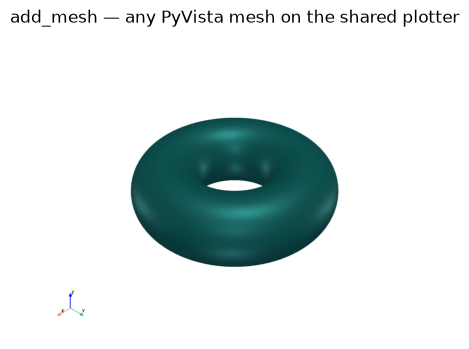

In [2]:
scene = Scene3D(off_screen=True)
scene.add_mesh(pv.ParametricTorus(), color='teal', show_edges=False, pbr=True, metallic=0.4)
scene.plotter.add_axes()
print('layers registered:', len(scene.layers))
show(scene, 'add_mesh — any PyVista mesh on the shared plotter')
scene.close()

## Saving — PNG screenshot or interactive HTML

`save()` writes a PNG screenshot for any normal path, or a self-contained interactive HTML page (trame / vtk.js) when the path ends in `.html`. `screenshot()` returns the RGB frame as a NumPy array; `export_html()` is the explicit HTML form.

In [3]:
import tempfile, os
tmp = Path(tempfile.mkdtemp())
scene = Scene3D(off_screen=True)
scene.add_mesh(pv.Cube(), color='goldenrod', show_edges=True)
png = scene.save(str(tmp / 'cube.png'))          # returns the RGB frame
html = scene.save(str(tmp / 'cube.html'))        # returns None — writes an interactive page
print('screenshot array :', type(png).__name__, getattr(png, 'shape', None))
print('png  bytes :', os.path.getsize(tmp / 'cube.png'))
print('html bytes :', os.path.getsize(tmp / 'cube.html'))
scene.close()

screenshot array : ndarray (768, 1024, 3)
png  bytes : 38410
html bytes : 1063299


## Context-manager lifecycle

Used as a context manager, `Scene3D` closes its plotter (frees the render window) on exit — handy in loops/batch so windows don't leak.

In [4]:
with Scene3D(off_screen=True) as scene:
    scene.add_mesh(pv.Sphere(), color='slateblue')
    frame = scene.screenshot()
    print('rendered frame:', frame.shape)
print('plotter closed on exit')

rendered frame: (768, 1024, 3)
plotter closed on exit
